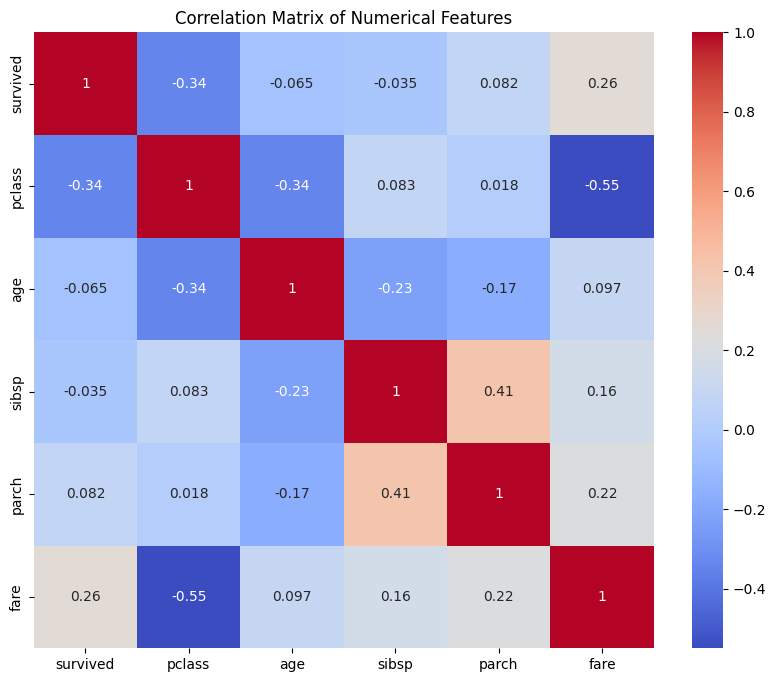

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


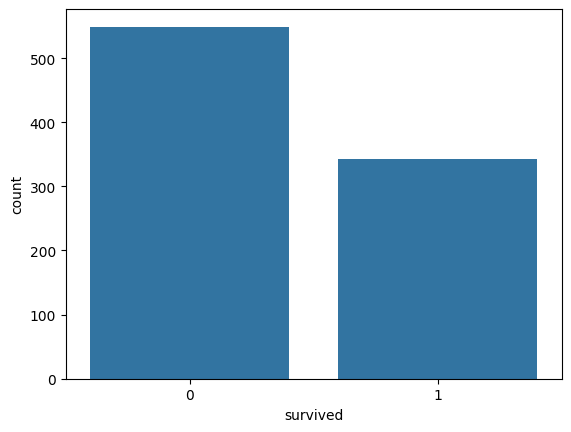

In [8]:
sns.countplot(x="survived", data=df)
plt.show()

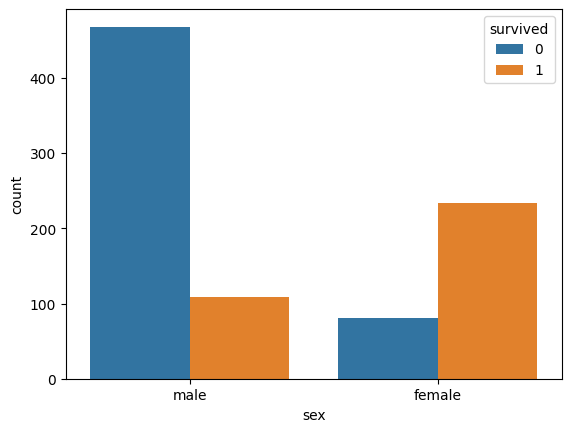

In [11]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("titanic.csv")
sns.countplot(x="sex", hue="survived", data=df)
plt.show()

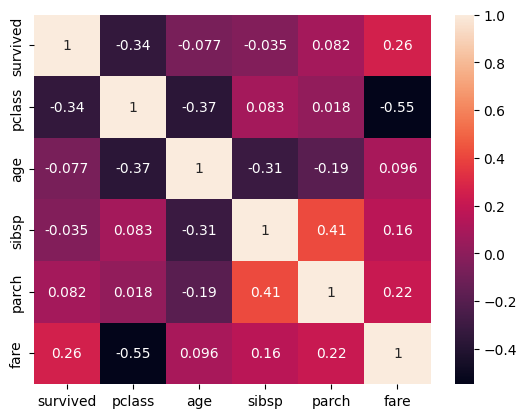

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True)
plt.show()

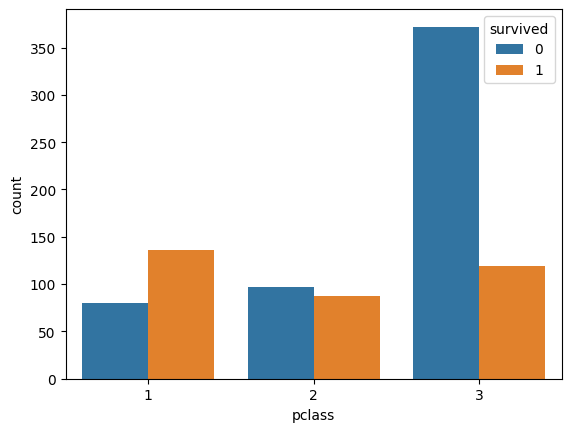

In [7]:
sns.countplot(x="pclass", hue="survived", data=df)
plt.show()

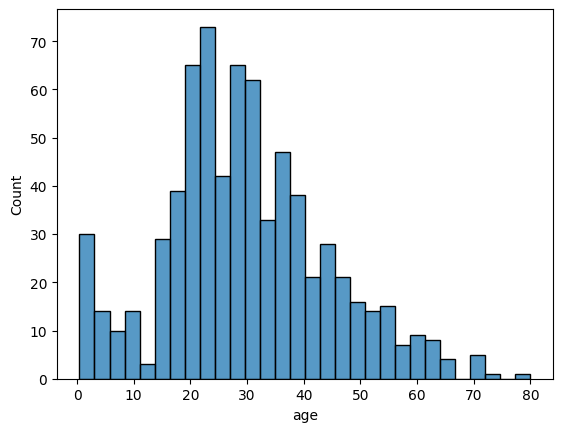

In [8]:
sns.histplot(df["age"], bins=30)
plt.show()

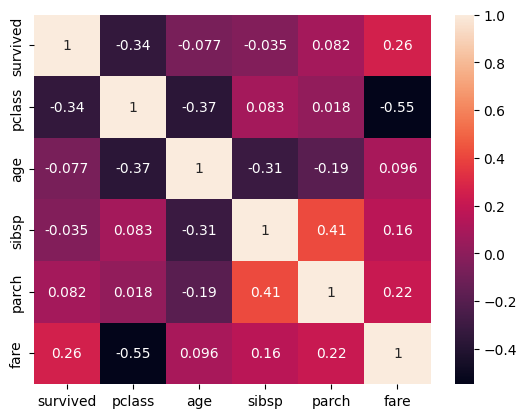

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True)
plt.show()

In [17]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["deck"] = df["deck"].fillna("Unknown")

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.994413407821229
[[104   1]
 [  0  74]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       105
           1       0.99      1.00      0.99        74

    accuracy                           0.99       179
   macro avg       0.99      1.00      0.99       179
weighted avg       0.99      0.99      0.99       179

